# 14장 실습 — 과제 다양성 갭

12장과 13장은 시뮬 데이터가 **어떻게 보이는가**를 다뤘다. 관측이 실기와 얼마나 닮았는지, 그 차이를 어떻게 메우는지였다.

이 장의 질문은 다른 축이다. **무엇을 시키는가.**

시뮬 데이터는 공짜에 가깝다. 그런데 공짜인 것을 무한정 만든다고 정책이 좋아지지는 않는다. 같은 과제를 천 번 시연한 데이터와 천 가지 과제를 한 번씩 시연한 데이터는 크기가 같아도 가치가 다르다. 이 노트북은 그 차이를 잰다.

실행 시간은 CPU에서 4분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


## 과제를 절차적으로 만든다

과제 하나는 네 수로 정해진다 — 목표의 거리와 각도, 블록의 마찰, 질량, 반지름이다. 난수로 뽑으면 과제가 생긴다. GenSim 계열이 언어 모델로 과제 자체를 만들어 내는 것의 아주 작은 판본이라고 보면 된다.

시뮬과 실기의 차이는 이 노트북에서 다루지 않는다. 도메인은 하나뿐이고, 재는 것은 **학습한 과제에서 배운 것이 처음 보는 과제로 얼마나 넘어가는가**다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size="{sz} .03" mass="{ms}"
            friction="{mu} .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
CACHE = {}


def model_of(mu, ms, sz):
    k = (round(mu, 2), round(ms, 2), round(sz, 3))
    if k not in CACHE:
        CACHE[k] = mujoco.MjModel.from_xml_string(
            XML.format(mu=k[0], ms=k[1], sz=k[2]))
    return CACHE[k]


def task(rng):
    r = rng.uniform(.22, .38)
    th = rng.uniform(-.35, .35)
    return dict(goal=np.array([r * np.cos(th), r * np.sin(th)]),
                mu=float(rng.uniform(.5, .9)),
                ms=float(rng.uniform(.15, .5)),
                sz=float(rng.uniform(.025, .038)))


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else np.zeros_like(v)


def expert(b, p, g):
    dv = unit(g - b)
    if np.linalg.norm(g - b) < .012:
        return np.zeros(2)
    e = (b - dv * .05) - p
    if np.linalg.norm(e) > .013:
        u = 14. * e
        n = np.linalg.norm(u)
        return u / n * .22 if n > .22 else u
    return dv * .22

## 관측을 두 가지로 둔다

여기서 손잡이가 하나 더 붙는다. 같은 상태를 **두 좌표계**로 적을 수 있다.

- **절대 좌표** — 블록의 위치, 블록의 속도, 밀대의 위치, 그리고 목표의 위치. 네 쌍 모두 세계 좌표다
- **과제 상대 좌표** — 목표에서 블록을 뺀 것, 블록에서 밀대를 뺀 것. 목표가 어디에 있든 같은 숫자가 나온다

영상을 입력으로 받는 정책은 앞쪽에 가깝다. 카메라 좌표계에 놓인 화소를 보지, 과제에 맞춰 정렬된 벡터를 받지 않는다. 뒤쪽은 우리가 손으로 과제 구조를 넣어 준 경우다.

같은 실험을 두 좌표계에서 돌리는 것이 이 노트북의 두 번째 축이다.

In [4]:
def obs_of(d, g, frame, ob):
    if frame == "abs":
        return np.concatenate([ob, d.qvel[0:2], d.qpos[7:9],
                               g]).astype(np.float32) * 10.
    return np.concatenate([g - ob, d.qvel[0:2], ob - d.qpos[7:9],
                           d.qvel[6:8]]).astype(np.float32) * 10.


def rollout(tk, rng, frame, pol=None, keep=False, noise=0.):
    m = model_of(tk["mu"], tk["ms"], tk["sz"])
    d = mujoco.MjData(m)
    sub = int(round(1 / 20 / m.opt.timestep))
    bx, by = rng.uniform(-.03, .03, 2)
    d.qpos[0:2] = [bx, by]
    d.qpos[2] = .031
    d.qpos[7:9] = [bx - .09, by]
    mujoco.mj_forward(m, d)
    g = tk["goal"]
    log = []
    for t in range(EP):
        b = np.asarray(d.qpos[0:2], float)
        ob = b + rng.normal(0, noise, 2) if noise else b
        o = obs_of(d, g, frame, ob)
        if pol is None:
            a = expert(b, np.asarray(d.qpos[7:9], float), g)
        else:
            a = pol(o)
        a = np.clip(a, -AMAX, AMAX)
        if keep:
            log.append((o, a / AMAX))
        d.ctrl[:] = a
        for _ in range(sub):
            mujoco.mj_step(m, d)
    ok = np.linalg.norm(d.qpos[0:2] - g) < GOAL_R
    return (ok, log) if keep else ok


def collect(tasks, per, frame, seed, noise=0.):
    X, Y = [], []
    rng = np.random.default_rng(seed)
    for tk in tasks:
        got = tries = 0
        while got < per and tries < per * 5:
            tries += 1
            ok, log = rollout(tk, rng, frame, keep=True,
                              noise=noise)
            if not ok:
                continue
            got += 1
            for o, a in log:
                X.append(o)
                Y.append(a)
    return np.array(X, np.float32), np.array(Y, np.float32)

In [5]:
class BC(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(8, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 2))

    def forward(self, x):
        return self.f(x)


def train_bc(X, Y, seed=0, epochs=150):
    torch.manual_seed(seed)
    net = BC()
    opt = torch.optim.Adam(net.parameters(), 1e-3)
    X, Y = torch.from_numpy(X), torch.from_numpy(Y)
    n = len(X)
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 256):
            j = idx[k:k + 256]
            loss = ((net(X[j]) - Y[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return net


def evaluate(net, tasks, frame, n_per=2, seed=999):
    rng = np.random.default_rng(seed)

    def pol(o):
        with torch.no_grad():
            return net(torch.from_numpy(o)).numpy() * AMAX
    return float(np.mean([rollout(tk, rng, frame, pol=pol)
                          for tk in tasks for _ in range(n_per)]))


HELD = [task(np.random.default_rng(5000 + i)) for i in range(60)]
exp = np.mean([rollout(tk, np.random.default_rng(i), "abs")
               for i, tk in enumerate(HELD)])
print(f"처음 보는 과제 60종에서 전문가의 성공률 {exp:.2f}")

처음 보는 과제 60종에서 전문가의 성공률 0.90


## 같은 예산, 다른 나눔

시연 120판으로 예산을 고정한다. 그 120판을 과제 몇 종에 나눌지만 바꾼다.

한쪽 끝은 **한 과제를 120번** 시연한 것이고, 다른 끝은 **120가지 과제를 한 번씩** 시연한 것이다. 샘플 수는 같다.

In [6]:
TOTAL = 120
SPLITS = (1, 4, 15, 60, 120)
res = []
t0 = time.time()
for K in SPLITS:
    M = TOTAL // K
    tasks = [task(np.random.default_rng(100 + i)) for i in range(K)]
    X, Y = collect(tasks, M, "abs", 1)
    res.append(evaluate(train_bc(X, Y), HELD, "abs"))
    print(f"{K}종 끝  ({time.time()-t0:.0f}s)")

print()
print(pad("나눔", 18) + pad("샘플", 12, True)
      + pad("처음 보는 과제", 16, True))
for K, v in zip(SPLITS, res):
    print(pad(f"{K}종 × {TOTAL//K}판", 18)
          + pad(f"{K*(TOTAL//K)*EP:,}", 12, True)
          + pad(f"{v:.2f}", 16, True))

1종 끝  (12s)


4종 끝  (23s)


15종 끝  (34s)


60종 끝  (45s)


120종 끝  (56s)

나눔                      샘플  처음 보는 과제
1종 × 120판             13,200            0.15
4종 × 30판              13,200            0.62
15종 × 8판              13,200            0.93
60종 × 2판              13,200            0.82
120종 × 1판             13,200            0.95


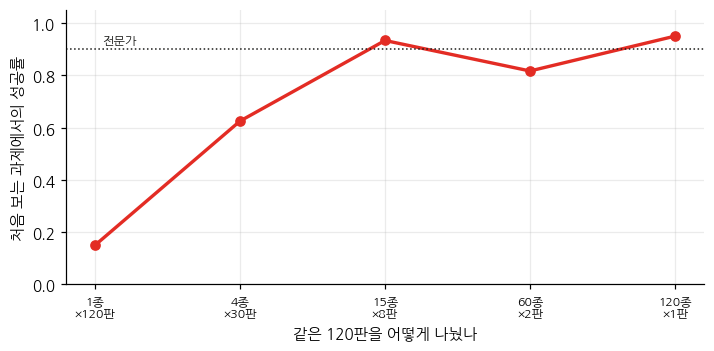

In [7]:
xs = np.arange(len(SPLITS))
fig, ax = plt.subplots(figsize=(6.6, 3.3))
ax.plot(xs, res, "o-", color=RED, lw=2.2, ms=6)
ax.axhline(exp, color=INK, lw=1, ls=":")
ax.text(.05, exp + .02, "전문가", fontsize=8, color=INK)
ax.set_xticks(xs)
ax.set_xticklabels([f"{K}종\n×{TOTAL//K}판" for K in SPLITS],
                   fontsize=8)
ax.set_xlabel("같은 120판을 어떻게 나눴나")
ax.set_ylabel("처음 보는 과제에서의 성공률")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 표현이 다양성을 대신할 수 있다

그런데 이 결핍은 데이터로만 메우는 것이 아니다. 같은 상태를 **과제에 맞춰 정렬해서** 적어 주면 사라진다.

같은 1종 × 120판 데이터를 두 좌표계로 적어 견줘 본다.

In [8]:
tasks1 = [task(np.random.default_rng(100))]
row = []
for frame in ("abs", "rel"):
    X, Y = collect(tasks1, TOTAL, frame, 1)
    row.append(evaluate(train_bc(X, Y), HELD, frame))

print(pad("1종 × 120판을 적는 방식", 26)
      + pad("처음 보는 과제", 16, True))
print(pad("절대 좌표", 26) + pad(f"{row[0]:.2f}", 16, True))
print(pad("과제 상대 좌표", 26) + pad(f"{row[1]:.2f}", 16, True))

1종 × 120판을 적는 방식     처음 보는 과제
절대 좌표                             0.15
과제 상대 좌표                        0.72


## 더 많이 보여 주면 되는가

한 과제만 있는 상황에서 데이터를 늘리는 다른 방법도 있다. 관측에 잡음을 섞어 다양하게 만드는 것이다. 증강이라는 이름으로 흔히 하는 일이고, 13장에서 본 「모습을 바꾸는」 증강과 같은 자리에 있다.

절대 좌표, 한 과제, 120판에 관측 잡음만 얹어 본다.

In [9]:
t0 = time.time()
rows = []
for nz in (0., .005, .015, .03):
    tasks = [task(np.random.default_rng(100))]
    X, Y = collect(tasks, TOTAL, "abs", 1, noise=nz)
    net = train_bc(X, Y)
    rows.append((nz, evaluate(net, HELD, "abs")))
print(f"({time.time()-t0:.0f}s)")
print()
print(pad("관측 잡음", 14) + pad("처음 보는 과제", 16, True))
for nz, v in rows:
    print(pad(f"{nz*1000:.0f} mm", 14) + pad(f"{v:.2f}", 16, True))
print()
print(f"참고 — 과제 120종 × 1판: {res[-1]:.2f}")

(44s)

관측 잡음       처음 보는 과제
0 mm                      0.15
5 mm                      0.17
15 mm                     0.14
30 mm                     0.11

참고 — 과제 120종 × 1판: 0.95


## 정리

**같은 예산이면 다양성이 판수를 이긴다.** 120판을 한 과제에 몰면 처음 보는 과제에서 거의 못 했고, 120가지 과제에 한 판씩 나누면 전문가에 가까웠다.

**다만 다양성이 사는 것은 불변성이다.** 같은 1종 × 120판이라도 과제 상대 좌표로 적으면 성적이 크게 올랐다. 불변성을 표현으로 주지 않으면 데이터로 사야 한다.

**관측 증강은 과제 다양성을 대신하지 못한다.** 잡음을 얹어도 목표가 다른 방향에 있는 상황은 만들어지지 않는다.

**두 축을 따로 예산 잡는다.** 얼마나 진짜처럼 보이게 할 것인가와 무엇을 몇 가지나 시킬 것인가는 서로 다른 문제다.

여기까지 4부는 데이터를 만드는 쪽을 봤다. 남은 한 장은 방향을 돌려 묻는다 — 지금까지 다룬 두 갈래의 갭 중 **어느 쪽을 먼저 메워야 하는가.** 답이 정책의 종류에 따라 갈린다.